## Imports and Constants/Experiment Setup

In [ ]:
import torch
from torchvision import transforms

import uconn_ballots_dino_v3_model
import uccon_ballots_dataset
from warmup_cosine_annealing_lr import WarmupCosineAnnealingLR
from validate_uconn_dataset import validate_uconn, validate_model, validate_dataset, validate_model_loads_dataset
from train_helper_funcs import ProgressTracker, CheckpointManager, _count_correct, _compute_accuracy


DATASET_ROOT = "./uconn_voter_center_v2_2/FINALDATASETV3/preprint/" # Path to the root directory containing the dataset .pth files, using preprint version as default
VARIANT = "Combined_Grayscale" # Options: "Combined_Grayscale", "Combined_RGB", "OnlyBubbles_Grayscale", "OnlyBubbles_RGB", etc

# CHECKPOINTING
SAVE_CHECKPOINTS = True
CHECKPOINT_DIR = "./checkpoints/"
CHECKPOINT_MODE = "best"  # Options: "best", "last", "both"

class Ensure3Channels:
    def __call__(self, x):
        if x.shape[0] == 1:
            return x.repeat(3, 1, 1)
        return x
    
# Define data augmentations/transforms:
augmentations = transforms.Compose([
        transforms.Resize((224, 224), antialias=True),
        Ensure3Channels(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),# ImageNet normalization
    ])

## Validate Model/Dataset

In [22]:
validate_model_loads_dataset(root=DATASET_ROOT, variant=VARIANT, transforms=augmentations)

Loaded test split from D:\MLSEC-Final\CSC592-MLSEC-InstantPure\uconn_voter_center_v2_2\FINALDATASETV3\split_Combined_Grayscale.txt (1000 samples)
Variant:    Combined_Grayscale  |  channels: 1
Train size: 42679
Val size:   9652
Test size:  1000
Root:       D:\MLSEC-Final\CSC592-MLSEC-InstantPure\uconn_voter_center_v2_2\FINALDATASETV3
Train loader batches: 1334, Val loader batches: 302, Test loader batches: 32
Testing model forward pass with one batch from the training loader...
Input batch shape: torch.Size([32, 3, 224, 224]), Labels shape: torch.Size([32])
Model output shape: torch.Size([32, 2])


## Training Config and DataLoaders

In [ ]:
# Train Config:
config = {
    "batch_size": 32,
    "num_epochs": 5,
    "learning_rate": 0.001,
    "num_workers": 0,
    "pin_memory": False,
    "persistent_workers": False,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "criterion": torch.nn.CrossEntropyLoss(),
    "num_warmup_epochs": 0,
    "T_max": 5,
    "eta_min": 1e-6,
}



# Get DataLoaders:
train_loader, val_loader, test_loader = uccon_ballots_dataset.get_uconn_dataloaders(
    batch_size=config["batch_size"],
    test_size=1000,
    test_source="val",
    variant=VARIANT,
    transform=augmentations,
    val_transform=augmentations,
    num_workers=config["num_workers"],
    pin_memory=config["pin_memory"],
    persistent_workers=config["persistent_workers"],
    seed=42,
)


Loaded test split from D:\MLSEC-Final\CSC592-MLSEC-InstantPure\uconn_voter_center_v2_2\FINALDATASETV3\split_Combined_Grayscale.txt (1000 samples)
Variant:    Combined_Grayscale  |  channels: 1
Train size: 42679
Val size:   9652
Test size:  1000
Root:       D:\MLSEC-Final\CSC592-MLSEC-InstantPure\uconn_voter_center_v2_2\FINALDATASETV3


## Model Training

In [24]:
# Build Model:
model = uconn_ballots_dino_v3_model.DINOv3UConnModel(num_classes=2, freeze_backbone=True)
model = model.to(config["device"])

# Set up optimizer, criterion, and scheduler:
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"])
criterion = config["criterion"]
#scheduler = WarmupCosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6, start_factor=0.1, warmup_iters=5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["T_max"], eta_min=config["eta_min"])

# Pull out some config values for convenience:
epochs = config["num_epochs"]
device = config["device"]

# Set up checkpoint manager:
checkpoint_config = {
     "enabled": SAVE_CHECKPOINTS,
     "mode": CHECKPOINT_MODE,
     "dir": CHECKPOINT_DIR,
     "monitor": "val_loss",
     "every_n_epochs": 1,
}

checkpoint_manager = CheckpointManager(checkpoint_config, CHECKPOINT_DIR)

# ====== Training Loop ====== #
for epoch in range(epochs):
        # Set model to training mode
        model.train()
        # Initialize metrics
        train_loss = 0.0
        train_correct = 0
        train_samples = 0

        # Create a progress tracker for the training loop
        tracker = ProgressTracker(len(train_loader))

        # Iterate over training batches
        for batch_idx, batch in enumerate(train_loader):
            # Move data to the appropriate device
            data, target, *_ = batch
            data, target = data.to(device), target.to(device)
            
            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            preds = model(data)
            # Compute loss
            loss = criterion(preds, target)
            train_loss += loss.item()

            # Backward pass and optimization step
            loss.backward()
            optimizer.step()

            # Update training metrics
            train_correct += _count_correct(preds, target)
            train_samples += target.size(0)

            # Update progress tracker
            tracker.update(batch_idx)

        # Finish progress tracking for the epoch
        tracker.finish()

        # Set model to evaluation mode and initialize validation metrics
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_samples = 0

        # Evaluate on validation set without tracking gradients
        with torch.inference_mode():
            for batch in val_loader:
                data, target, *_ = batch
                data, target = data.to(device), target.to(device)

                # Forward pass
                preds = model(data)

                # Compute loss
                loss = criterion(preds, target)
                val_loss += loss.item()

                # Update validation metrics
                val_correct += _count_correct(preds, target)
                val_samples += target.size(0)

        # Compute mean losses and accuracies
        mean_train_loss = train_loss / len(train_loader)
        mean_val_loss = val_loss / len(val_loader)
        train_acc = _compute_accuracy(train_correct, train_samples)
        val_acc = _compute_accuracy(val_correct, val_samples)

        epoch_metrics = {
            "train_loss": mean_train_loss,
            "val_loss": mean_val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
        }

        scheduler.step()
        checkpoint_manager.step(epoch, model, optimizer, scheduler, epoch_metrics)

        print(
            f"EPOCH: {epoch} | "
            f"Train Loss: {mean_train_loss:.4f} | Train Acc: {train_acc:.4%} | "
            f"Val Loss: {mean_val_loss:.4f} | Val Acc: {val_acc:.4%}"
        )

1334/1334 | batch 0.037s | avg 0.047s | eta 0.0ss
EPOCH: 0 | Train Loss: 0.0091 | Train Acc: 99.7798% | Val Loss: 0.0701 | Val Acc: 99.5027%
1334/1334 | batch 0.040s | avg 0.046s | eta 0.0ss
EPOCH: 1 | Train Loss: 0.0073 | Train Acc: 99.8524% | Val Loss: 0.0338 | Val Acc: 99.5545%
1334/1334 | batch 0.042s | avg 0.050s | eta 0.0ss
EPOCH: 2 | Train Loss: 0.0069 | Train Acc: 99.8290% | Val Loss: 0.0358 | Val Acc: 99.5338%
1334/1334 | batch 0.036s | avg 0.047s | eta 0.0ss
EPOCH: 3 | Train Loss: 0.0047 | Train Acc: 99.8594% | Val Loss: 0.0443 | Val Acc: 99.5131%
1334/1334 | batch 0.035s | avg 0.046s | eta 0.0ss
EPOCH: 4 | Train Loss: 0.0043 | Train Acc: 99.8922% | Val Loss: 0.0296 | Val Acc: 99.5545%


## Model Testing

In [25]:
# Set model to evaluation mode and initialize test metrics
model.eval()
test_loss = 0.0
test_correct = 0
test_samples = 0

# Evaluate on test set without tracking gradients
with torch.inference_mode():
    for batch in test_loader:
        data, target, *_ = batch
        data, target = data.to(device), target.to(device)

        preds = model(data)
        loss = criterion(preds, target)
        test_loss += loss.item()

        test_correct += _count_correct(preds, target)
        test_samples += target.size(0)

mean_test_loss = test_loss / len(test_loader)
test_acc = _compute_accuracy(test_correct, test_samples)

print(f"TEST Loss: {mean_test_loss:.4f} | Test Acc: {test_acc:.4%}")

TEST Loss: 0.0207 | Test Acc: 99.8000%


In [26]:
# Load best model for final evaluation on test set

best_model_path = "./checkpoints/checkpoints/best.pt"
best_model = uconn_ballots_dino_v3_model.DINOv3UConnModel(num_classes=2)
best_model.load_state_dict(torch.load(best_model_path)["model_state_dict"])
best_model = best_model.to('cuda' if torch.cuda.is_available() else 'cpu')
best_model.eval()

criterion = config["criterion"]

test_loss = 0.0
test_correct = 0
test_samples = 0
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Evaluate on test set without tracking gradients
with torch.inference_mode():
    for batch in test_loader:
        data, target, *_ = batch
        data, target = data.to(device), target.to(device)

        preds = best_model(data)
        loss = criterion(preds, target)
        test_loss += loss.item()

        test_correct += _count_correct(preds, target)
        test_samples += target.size(0)

mean_test_loss = test_loss / len(test_loader)
test_acc = _compute_accuracy(test_correct, test_samples)

print(f"TEST Loss: {mean_test_loss:.4f} | Test Acc: {test_acc:.4%}")


TEST Loss: 0.0207 | Test Acc: 99.8000%


Incorrect predictions: 2 / 1000


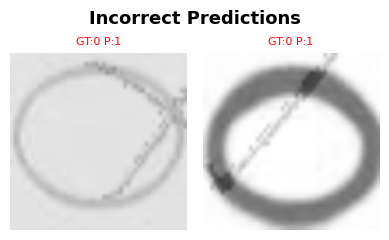

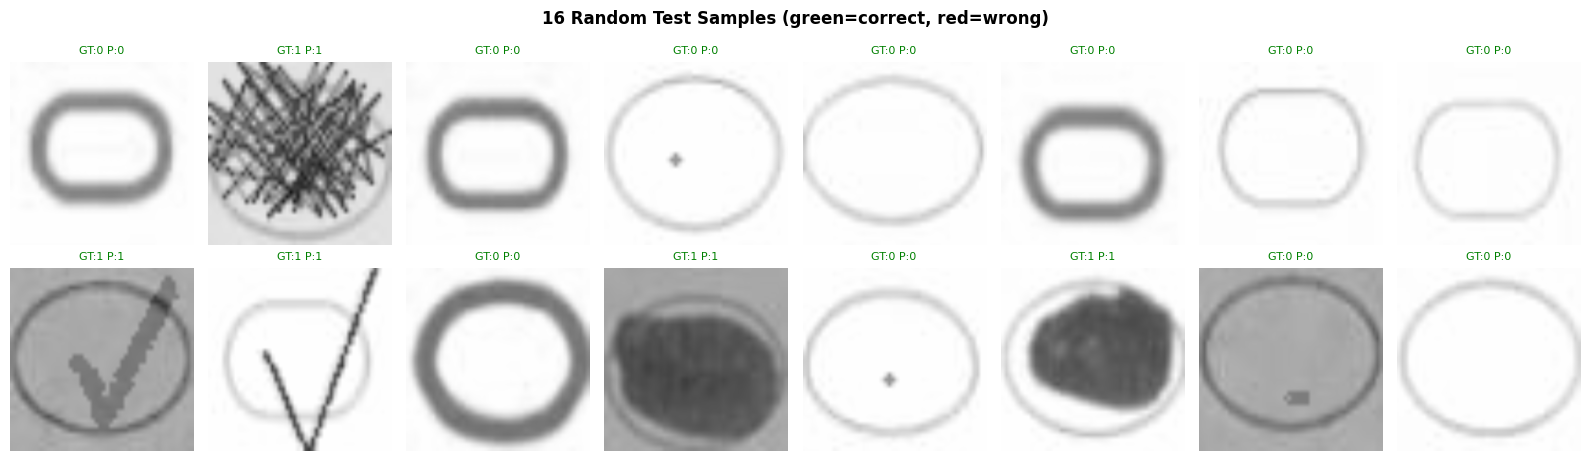

In [27]:
import matplotlib.pyplot as plt
import math

def denormalize(tensor, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    """Reverse ImageNet normalization for display."""
    t = tensor.clone().cpu().float()
    for c, m, s in zip(range(t.shape[0]), mean, std):
        t[c] = t[c] * s + m
    return t.permute(1, 2, 0).clamp(0, 1).numpy()

# Collect ALL test-set predictions
all_images, all_labels, all_preds = [], [], []

best_model.eval()
with torch.inference_mode():
    for batch in test_loader:
        imgs, lbls, *_ = batch
        imgs, lbls = imgs.to(device), lbls.to(device)
        out = best_model(imgs)
        pred = torch.argmax(out, dim=1)
        all_images.append(imgs.cpu())
        all_labels.append(lbls.cpu())
        all_preds.append(pred.cpu())

all_images = torch.cat(all_images)
all_labels = torch.cat(all_labels)
all_preds  = torch.cat(all_preds)

# Plot 1: All incorrect predictions
wrong_mask   = all_preds != all_labels
wrong_images = all_images[wrong_mask]
wrong_labels = all_labels[wrong_mask]
wrong_preds  = all_preds[wrong_mask]

n_wrong = len(wrong_images)
print(f"Incorrect predictions: {n_wrong} / {len(all_labels)}")

if n_wrong == 0:
    print("No incorrect predictions to display.")
else:
    cols = min(8, n_wrong)
    rows = math.ceil(n_wrong / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.4))
    axes = [axes] if rows == 1 and cols == 1 else axes
    axes_flat = [axes] if n_wrong == 1 else (axes if rows == 1 else [ax for row in axes for ax in row])
    for i, ax in enumerate(axes_flat):
        if i < n_wrong:
            ax.imshow(denormalize(wrong_images[i]))
            ax.set_title(f"GT:{wrong_labels[i].item()} P:{wrong_preds[i].item()}", fontsize=8, color="red")
        ax.axis("off")
    fig.suptitle("Incorrect Predictions", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Plot 2: N random samples from test set
N_RANDOM = 16
cols = min(8, N_RANDOM)
rows = math.ceil(N_RANDOM / cols)

indices = torch.randperm(len(all_images))[:N_RANDOM]
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.4))
axes_flat = [ax for row in axes for ax in row] if rows > 1 else list(axes)
for i, ax in enumerate(axes_flat):
    idx = indices[i].item()
    correct = all_preds[idx] == all_labels[idx]
    color = "green" if correct else "red"
    ax.imshow(denormalize(all_images[idx]))
    ax.set_title(f"GT:{all_labels[idx].item()} P:{all_preds[idx].item()}", fontsize=8, color=color)
    ax.axis("off")
fig.suptitle(f"{N_RANDOM} Random Test Samples (green=correct, red=wrong)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
